In [1]:
import os
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from paddleocr import PaddleOCR
from rapidfuzz import process, fuzz

plt.rcParams["figure.figsize"] = (10,6)

c:\Users\ambuj\AppData\Local\Programs\Python\Python310\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [21]:
ocr = PaddleOCR(
    use_angle_cls=True,
    lang="en"
)

print("OCR Loaded Successfully!")

[2026/07/23 11:27:55] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='C:\\Users\\ambuj/.paddleocr/whl\\det\\en\\en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='C:\\Users\\ambuj/.paddleocr/whl\\rec\\en\\en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=

In [4]:
IMAGE_FOLDER = r"E:\SIH\DATASET\IMAGES"

image_paths = []

for file in os.listdir(IMAGE_FOLDER):

    if file.lower().endswith((".jpg",".jpeg",".png")):

        image_paths.append(os.path.join(IMAGE_FOLDER,file))

print("Images :",len(image_paths))

Images : 437


(-0.5, 1547.5, 1339.5, -0.5)

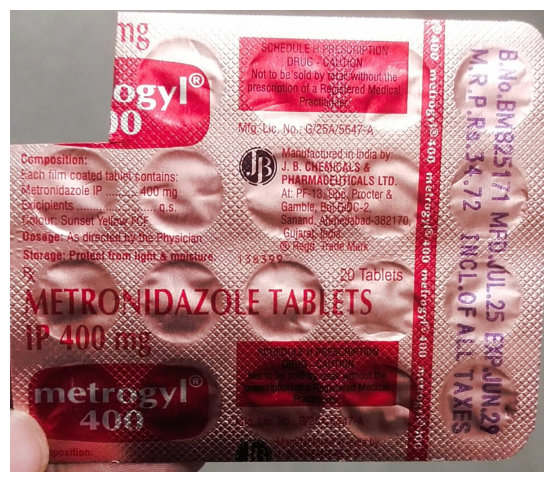

In [29]:
TEST_IMAGE = r"E:\SIH\DATASET\demo_metronidazole.jpg"

img = cv2.imread(TEST_IMAGE)

plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

plt.axis("off")

In [22]:
result = ocr.ocr(TEST_IMAGE, cls=True)

[2026/07/23 11:29:19] ppocr DEBUG: dt_boxes num : 46, elapsed : 0.30640435218811035
[2026/07/23 11:29:19] ppocr DEBUG: cls num  : 46, elapsed : 0.16499972343444824
[2026/07/23 11:29:23] ppocr DEBUG: rec_res num  : 46, elapsed : 3.9058895111083984


In [7]:
for line in result[0]:

    print(line[1][0])

mg
SCHEDULERE
SORPTION
M.R.P.R34.72 NCL.0FATAXES
B.No.BM325171 MR3JUL.25EXPJUN.29
DRUG
AECION
Not to be sold by taswithoutthe
R
ogyl
prescription of a Regrsered Medica
Practitoae
Mg.ticNO.GI25A/5647-A
Manuracturedio-ndia by
Somposition:
J.B.CHES&
Sach illm coated tabet contains
PHARMAGEACALS LTD
Metronidazole IP
400 mg
AtPF-13.pProcter &
xicipients
q.s.
Gamble.BacDC-2
Hour Sunset Yeliawero.
Sanand.sabad-382170
Dosage: As dirscteMseone Physician
Guieratsoa
Onegs.adewan
Storage:Prolesnrogshgnt & moistre
68399
Tablets
METROSIDAZQLE TABLETS
P-400
lottobesold
oAnthoutthe
metregyl
rescnotion
RaredMedical
Pr
408
osition:


In [8]:
text = []

confidence = []

for line in result[0]:

    text.append(line[1][0])

    confidence.append(line[1][1])

ocr_text = " ".join(text)

avg_conf = np.mean(confidence)

print(ocr_text)

print()

print("Average Confidence :",avg_conf)

mg SCHEDULERE SORPTION M.R.P.R34.72 NCL.0FATAXES B.No.BM325171 MR3JUL.25EXPJUN.29 DRUG AECION Not to be sold by taswithoutthe R ogyl prescription of a Regrsered Medica Practitoae Mg.ticNO.GI25A/5647-A Manuracturedio-ndia by Somposition: J.B.CHES& Sach illm coated tabet contains PHARMAGEACALS LTD Metronidazole IP 400 mg AtPF-13.pProcter & xicipients q.s. Gamble.BacDC-2 Hour Sunset Yeliawero. Sanand.sabad-382170 Dosage: As dirscteMseone Physician Guieratsoa Onegs.adewan Storage:Prolesnrogshgnt & moistre 68399 Tablets METROSIDAZQLE TABLETS P-400 lottobesold oAnthoutthe metregyl rescnotion RaredMedical Pr 408 osition:

Average Confidence : 0.8620604035400209


In [24]:
master_df = pd.read_csv(

r"E:\SIH\DATASET\CSV\master_final.csv"

)

# master_df.head()

In [23]:

medicine_names = (
    master_df["Drug_Name"]
    .fillna("")
    .astype(str)
    .tolist()
)

print("Medicines :", len(medicine_names))

Medicines : 707


In [20]:
best_match = None
best_score = 0

for line in result[0]:

    text = line[1][0]

    match = process.extractOne(
        text,
        medicine_names,
        scorer=fuzz.token_sort_ratio
    )

    if match and match[1] > best_score:

        best_match = match
        best_score = match[1]

print(best_match)

('Metronidazole Tablets IP 400 mg', 68.08510638297872, 292)


In [26]:
# EXTRACTING BATCH NUMBER BECAUSE.....IDK WHY BUT IT SEEMS IMPORTANT 
batch_pattern = r"(?:B\.?No\.?|Batch(?: No\.?)?)\s*[:\-]?\s*([A-Z0-9\-]+)"

batch = re.findall(
    batch_pattern,
    ocr_text,
    flags=re.IGNORECASE
)

print(batch)

['BM325171']


In [27]:
manufacturer = ""

for line in result[0]:

    txt = line[1][0]

    if any(word in txt.lower() for word in [
        "pharma",
        "pharmaceutical",
        "laboratories",
        "healthcare",
        "lifesciences",
        "limited",
        "ltd"
    ]):

        manufacturer += txt + " "

print(manufacturer)

PHARMAGEACALS LTD 


In [28]:
print("="*60)

print("TRUE MEDS REPORT")

print("="*60)

print(f"Medicine           : {best_match[0]}")
print(f"Similarity Score   : {best_match[1]:.2f}%")
print(f"OCR Confidence     : {avg_conf:.3f}")
print(f"Batch Number       : {batch}")

print("="*60)

TRUE MEDS REPORT
Medicine           : Metronidazole Tablets IP 400 mg
Similarity Score   : 68.09%
OCR Confidence     : 0.862
Batch Number       : ['BM325171']
